In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_recall_curve, auc
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold



#Importando e entendendo a base de dados


In [ ]:
ocorrencias_selec = pd.read_csv("/content/ocorrencias_aeronauticas_arquivo_original.csv", sep=';',on_bad_lines='skip')
ocorrencias_selec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5021 entries, 0 to 5020
Data columns (total 45 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Numero_da_Ocorrencia              5021 non-null   int64  
 1   Numero_da_Ficha                   5019 non-null   object 
 2   Operador_Padronizado              4945 non-null   object 
 3   Classificacao_da_Ocorrencia       5021 non-null   object 
 4   Data_da_Ocorrencia                5021 non-null   object 
 5   Hora_da_Ocorrencia                3588 non-null   object 
 6   Municipio                         3627 non-null   object 
 7   UF                                5018 non-null   object 
 8   Regiao                            4351 non-null   object 
 9   Descricao_do_Tipo                 4379 non-null   object 
 10  ICAO                              1687 non-null   object 
 11  Latitude                          3531 non-null   object 
 12  Longit

#Feature Engineering

- Criação e transformação de Varivaveis do nosso modelo

In [ ]:
#Definição da funcao para converter a string de hora em formato de data e podermos extrair a hora de incidência
def get_hour_from_time_string(time_str):
    if pd.isna(time_str):
        return np.nan
    try:

        return pd.to_datetime(time_str, format='%H:%M:%S').hour
    except ValueError:
        try:

            return pd.to_datetime(time_str, format='%H:%M').hour
        except ValueError:

            return np.nan
ocorrencias_selec['Hora_da_Ocorrencia'] = ocorrencias_selec['Hora_da_Ocorrencia'].apply(get_hour_from_time_string)


#Definição da variavel do Turno do dia em que a acidente ocorreu, de acordo com a hora do acidente.
ocorrencias_selec['periodo'] = ocorrencias_selec['Hora_da_Ocorrencia'].apply(
    lambda h: 'manhã' if pd.notna(h) and 6 <= h < 12
    else 'tarde' if pd.notna(h) and 12 <= h < 18
    else 'noite' if pd.notna(h)
    else np.nan
)



#a criação da variavel Trimestre, para sabermos em qual 1/4 do ano que foi o acidente.
ocorrencias_selec['Data_da_Ocorrencia'] = pd.to_datetime(ocorrencias_selec['Data_da_Ocorrencia'], errors='coerce')
ocorrencias_selec["mes"] = ocorrencias_selec['Data_da_Ocorrencia'].dt.month
ocorrencias_selec['trimestre'] = ocorrencias_selec['mes'].apply(
    lambda m: '1º trimestre' if 1 <= m <= 3
    else '2º trimestre' if 4 <= m <= 6
    else '3º trimestre' if 7 <= m <= 9
    else '4º trimestre' if 10 <= m <= 12
    else None
)

ocorrencias_selec["decada"] = (
    ((ocorrencias_selec["Data_da_Ocorrencia"].dt.year // 10) * 10) % 100
).astype(str)


#Criação da Variavel Resposta do nosso modelo, a variável binaria, 0  se não houve, e 1 se houve fatalidade no acidente.
colunas_fatais_passageiros = ["Lesoes_Fatais_Tripulantes","Lesoes_Fatais_Passageiros","Lesoes_Fatais_Terceiros"]
ocorrencias_selec["Fatalidade"] = (ocorrencias_selec[colunas_fatais_passageiros].sum(axis=1) > 0).astype(int)




#Criação da Variavel "Porte", classificando o avião de acordo com o PMD dele
ocorrencias_selec["Porte"] = pd.cut(
    ocorrencias_selec["PMD"],
    bins=[-1,0, 5700, 15000, 50000, 1e9],
    labels=["Indeterminado","leve", "medio", "grande", "muito_grande"]
)


#Após analisar o grafico dos dados do PMD, percebe-se que os dados estão tem uma dispersão extrema, com 95% dos valores aproximadamente menos de 8000, enquanto temos ainda valores acima disso, que chega a 30000-50000.
#Portanto, achei cabível adicionar uma coluna do PMD com a transformação do log, para diminuir essa dispersão, e com isso, o modelo esocolher qual é mais útil e melhor dele usar.
ocorrencias_selec["PMD_log"] = np.log1p(ocorrencias_selec["PMD"])



#  Fase de Operação Agrupada em 4 Categorias Principais
fase_agrupada = {
    "Pouso": "Chegada",
    "Decolagem": "Saida",
    "Corrida após pouso": "Chegada",
    "OUTROS": "Outros",
    "Em rota": "Cruzeiro",
    "Manobra": "Saida",
    "Cruzeiro": "Cruzeiro",
    "Subida": "Saida",
    "Aproximação": "Chegada",
    "Especializada": "Outros",
    "Indeterminada": "Outros"
}

ocorrencias_selec["fase_agrupada"] = ocorrencias_selec["Fase_da_Operacao"].map(fase_agrupada)


# Fase agrupada em Crítico vs Não Crítico ( Crítico é onde tem mais margem de erro humano e propenso a ter acidentes)
critico = {
    "Pouso": 1,
    "Decolagem": 1,
    "Corrida após pouso": 1,
    "OUTROS": 0,
    "Em rota": 0,
    "Manobra": 0,
    "Cruzeiro": 0,
    "Subida": 1,
    "Aproximação": 1,
    "Especializada": 0,
    "Indeterminada": 0
}
ocorrencias_selec["critico"] = ocorrencias_selec["Fase_da_Operacao"].map(critico)

#Funcão para salvar imagens
def salvar(nome):
    plt.tight_layout()
    plt.savefig(nome, dpi=150, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_4901/2060255789.py:29: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  ocorrencias_selec['Data_da_Ocorrencia'] = pd.to_datetime(ocorrencias_selec['Data_da_Ocorrencia'], errors='coerce')


In [ ]:
col_a_remover = ["Fase_da_Operacao","mes","UF","Numero_da_Ocorrencia","Numero_da_Ficha","Operador_Padronizado","Municipio","Latitude","Longitude","Nome_do_Fabricante","Numero_de_Assentos","Modelo","Tipo_ICAO","Matricula","Operador","Historico","Classificacao_da_Ocorrencia","Danos_a_Aeronave"]
rem_status_passageiros = ["Lesoes_Fatais_Tripulantes","Lesoes_Fatais_Passageiros","Lesoes_Fatais_Terceiros","Lesoes_Graves_Tripulantes","Lesoes_Graves_Passageiros","Lesoes_Graves_Terceiros","Lesoes_Leves_Tripulantes","Lesoes_Leves_Passageiros","Lesoes_Leves_Terceiros","Ilesos_Tripulantes","Ilesos_Passageiros","Lesoes_Desconhecidas_Tripulantes","Lesoes_Desconhecidas_Passageiros","Lesoes_Desconhecidas_Terceiros"]
ocorrencias_selec = ocorrencias_selec.drop(col_a_remover, axis = 1)
col_a_remover2 = ["Hora_da_Ocorrencia","Data_da_Ocorrencia","Tipo_de_Aerodromo","ICAO"]
ocorrencias_selec = ocorrencias_selec.drop(rem_status_passageiros, axis = 1)
ocorrencias_selec = ocorrencias_selec.drop(col_a_remover2, axis = 1)

#Pré- Processamento de Dados

In [ ]:
#Realizei aqui a inspeção relativa dos valores faltantes por coluna. Os que tem menos de 30% de valores faltantes, eu substitui esses NaN em "Desconhecido"
#Pois dependendo das condições da aeronave, ou problemas técnicos, pode ter sido incapaz de medir aquela variavel, e portanto o seu valor faltante.
#E isso pode ser uma informação relevante pro modelo.
colunas_categoricas = ["Descricao_do_Tipo","Regiao","Tipo_de_Ocorrencia","Operacao","periodo","Fatalidade"]
ocorrencias_selec[colunas_categoricas].isnull().mean() * 100
ocorrencias_selec[colunas_categoricas] = ocorrencias_selec[colunas_categoricas].fillna('Desconhecido')



In [ ]:


#Definindo as colunas que nao serão variaveis dummies( as únicas não categóricias)
excecoes = ["PMD","PMD_log","Fatalidade"]
colunas_transf_dummies = ocorrencias_selec.columns.difference(excecoes).tolist()

#Isso tudo serviu para pegar as variaveis categoricas, ver quais valores elas assumem, com menos de 3% de recorrencia, e agrupar
# em uma categoria chamado Outros, para tambem nao criar uma coluna dummie para um valor que aparece, por exemplo,  apenas 3 vezes de 5000 no total.
col_categoricas = ocorrencias_selec.select_dtypes(exclude=['int32', 'float64']).columns
for col in col_categoricas:

    freq = ocorrencias_selec[col].value_counts(normalize=True)
    rare = freq[freq < 0.03].index
    if col != 'Porte':
      ocorrencias_selec[col] = ocorrencias_selec[col].replace(rare, 'OUTROS')

In [ ]:
#Aqui de fato eu realizei o OneHotEncoding, e transformei as variaveis categoricas em matrizes n-1 dimensionais
# para justamente evitar problemas de dependência linear.

ocorrencias_selec_final = pd.get_dummies(ocorrencias_selec, columns=colunas_transf_dummies, drop_first= True)
ocorrencias_selec_final.head(5)


,PMD,Fatalidade,PMD_log,Aerodromo_de_Destino_XXXX,Aerodromo_de_Origem_XXXX,CLS_H1T,CLS_L1P,CLS_L1T,CLS_L2J,CLS_L2P,...,decada_OUTROS,fase_agrupada_Cruzeiro,fase_agrupada_Outros,fase_agrupada_Saida,periodo_manhã,periodo_noite,periodo_tarde,trimestre_2º trimestre,trimestre_3º trimestre,trimestre_4º trimestre
0,658.0,1,6.490724,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,621.0,0,6.432940,True,True,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
2,1088.0,0,6.993015,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,4581.0,0,8.429891,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,1315.0,0,7.182352,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


#Treinamento dos Modelos e Tunagem dos Hiperparâmetros

In [ ]:
X = ocorrencias_selec_final.drop(["Fatalidade"], axis=1)
y = ocorrencias_selec_final["Fatalidade"]
X_train,X_test,y_train,y_test = train_test_split( X,y,test_size= 0.22 ,random_state = 21, stratify = y)

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=3,
    class_weight = 'balanced',
    random_state=7,
    n_jobs=-1,
    max_features = 'log2'
)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)
y_pred_new = (y_prob[:,1] > 0.45).astype(int)
print(classification_report(y_test, y_pred_new))
auc_score = roc_auc_score(y_test, y_prob[:, 1])
print(f"ROC AUC Score: {auc_score:.4f}")


              precision    recall  f1-score   support

           0       0.95      0.77      0.85       921
           1       0.41      0.82      0.55       184

    accuracy                           0.77      1105
   macro avg       0.68      0.79      0.70      1105
weighted avg       0.86      0.77      0.80      1105

ROC AUC Score: 0.8531


In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid_rf = {
    'n_estimators': [200, 400, 600],
    'max_depth': [8, 10, 15, None],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [3, 6, 10],
    'max_features': ['sqrt', 'log2']
}

search_rf = RandomizedSearchCV(
    rf,
    param_grid_rf,
    scoring='f1',
    cv=cv,
    n_iter=30,
    random_state=42
)
search_rf.fit(X_train, y_train)
print(search_rf.best_params_)

KeyboardInterrupt: 

In [ ]:
xgb = XGBClassifier(

    objective='binary:logistic',

    eval_metric='logloss',

    scale_pos_weight = 4186/835,

    random_state=42
)

param_grid_xgb = {

    'n_estimators': [100, 200, 300, 400],

    'max_depth': [3, 4, 5, 6],

    'learning_rate': [0.01, 0.03, 0.05, 0.1],

    'subsample': [0.7, 0.8, 0.9, 1.0],

    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],

    'min_child_weight': [1, 3, 5]
}

search_xgb = RandomizedSearchCV(

    xgb,

    param_grid_xgb,

    scoring='average_precision',

    cv=cv,

    n_iter=30,

    random_state=42,

    n_jobs=-1
)

search_xgb.fit(X_train, y_train)
print(search_xgb.best_params_)

{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [ ]:
best_xgb = search_xgb.best_estimator_
y_prob_xgb = best_xgb.predict_proba(X_test)

y_pred_xgb = (y_prob_xgb[:,1] > 0.45).astype(int)
print(classification_report(y_test, y_pred_xgb))

roc_auc_score(y_test, y_prob_xgb[:,1])

              precision    recall  f1-score   support

           0       0.96      0.71      0.82       921
           1       0.37      0.86      0.52       184

    accuracy                           0.74      1105
   macro avg       0.67      0.79      0.67      1105
weighted avg       0.86      0.74      0.77      1105



np.float64(0.8505759335316055)

##Analisando  a Importância das Variáveis e sua Influência no modelo

/tmp/ipykernel_4901/1776937139.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10["Variavel"] = top10["Variavel"].replace(nomes_bonitos)


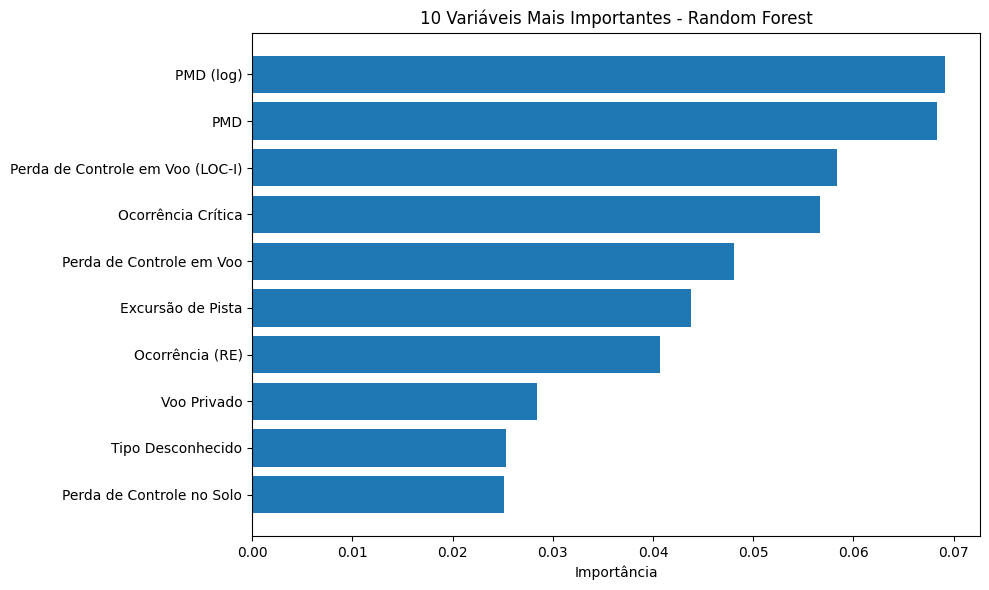

In [ ]:
#Top 10 variaveis(variavel + seu valor) mais influentes no nosso modelo
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': rf.feature_importances_
})

importancias = importancias.sort_values(
    by='Importancia',
    ascending=False
)

importancias.head(10)
top10 = importancias.head(10)
nomes_apresentaveis = {
    "PMD_log": "PMD (log)",
    "PMD": "PMD",

    "Tipo_de_Ocorrencia_LOC-I":
        "Perda de Controle em Voo (LOC-I)",

    "critico_1.0":
        "Ocorrência Crítica",

    "Descricao_do_Tipo_PERDA DE CONTROLE EM VOO":
        "Perda de Controle em Voo",

    "Descricao_do_Tipo_EXCURSÃO DE PISTA":
        "Excursão de Pista",

    "Tipo_de_Ocorrencia_RE":
        "Ocorrência (RE)",

    "Operacao_Voo Privado":
        "Voo Privado",

    "Tipo_de_Ocorrencia_UNK":
        "Tipo Desconhecido",

    "Descricao_do_Tipo_PERDA DE CONTROLE NO SOLO":
        "Perda de Controle no Solo"
}
top10["Variavel"] = top10["Variavel"].replace(nomes_apresentaveis)

plt.figure(figsize=(10,6))

plt.barh(
    top10['Variavel'][::-1],
    top10['Importancia'][::-1]
)

plt.xlabel('Importância')
plt.title('10 Variáveis Mais Importantes - Random Forest')

plt.tight_layout()
salvar('fig_top10_var.png')
plt.show()



In [ ]:
pd.crosstab(
    ocorrencias_selec['fase_agrupada'],
    ocorrencias_selec['Fatalidade'],
    normalize='index'
)
#A maior proporção de fatalidades não ocorre necessariamente nas fases críticas do voo.
#Observou-se que aproximadamente 23% dos acidentes ocorridos durante o cruzeiro resultaram em fatalidades.
#Isso sugere que, embora o cruzeiro seja uma fase operacionalmente estável, os acidentes que ocorrem nesse momento tendem a apresentar maior severidade.

pd.crosstab(
    ocorrencias_selec['critico'],
    ocorrencias_selec['Fatalidade'],
    normalize='index'
)

#Acidentes ocorridos em fases não críticas apresentaram maior proporção de fatalidades (26,5%) do que aqueles ocorridos em fases críticas (8%).
#Esse resultado indica que, apesar de termos uma frequência maior de acidentes na fase crítica,
# a gravidade do acidente quando não está na fase crítica, tende a ser maior.

Fatalidade,0,1
critico,,
0.0,0.736891,0.263109
1.0,0.916929,0.083071


In [ ]:



pd.crosstab(
    ocorrencias_selec['Tipo_de_Ocorrencia'],
    ocorrencias_selec['Fatalidade'],
    normalize='index'
)
#O código UNK apresentou aproximadamente 53% de fatalidades.
#Uma possível explicação é que acidentes extremamente severos podem causar danos tão extensos à aeronave
# que dificultam a identificação da ocorrência original, levando à classificação como "desconhecida".

#A ocorrência LOC-I (Perda de Controle em Voo) também apresentou elevada proporção de fatalidades, com 42.5%.
#Isso pode ser explicado pelo fato de que a perda de controle ocorre quando a aeronave já está em voo,
#muitas vezes em altitude elevada, reduzindo significativamente a capacidade de recuperação por parte da tripulação
#e fazendo com que o acidente, possivelmente tenha danos catastróficos

# o código de ocorrência CTOL (Collision with Obstacle during Takeoff and Landing) têm 25% de fatalidade.
#Isso porque, fatores como árvores, torres, linhas de transmissão, edificações ou outros obstáculos podem provocar impactos severos,
# comprometendo a integridade da aeronave e aumentando o risco de vítimas fatais.

Fatalidade,0,1
Tipo_de_Ocorrencia,,
ARC,0.989637,0.010363
CTOL,0.757991,0.242009
Desconhecido,0.700935,0.299065
LOC-G,0.981092,0.018908
LOC-I,0.574906,0.425094
OTHR,0.847015,0.152985
OUTROS,0.828526,0.171474
RE,0.986217,0.013783
SCF-NP,0.933921,0.066079


#Análise Exploratória de 3 das variáveis mais Influentes do modelo

#####PMD ( Peso Máximo de Decolagem)

In [ ]:
ocorrencias_selec.groupby('Fatalidade')['PMD'].describe()

,count,mean,std,min,25%,50%,75%,max
Fatalidade,,,,,,,,
0,4084.0,3777.905485,14314.266361,0.0,1043.0,1633.0,2155.0,346544.0
1,792.0,2244.720960,5210.139237,0.0,1089.0,1542.0,2155.0,79000.0


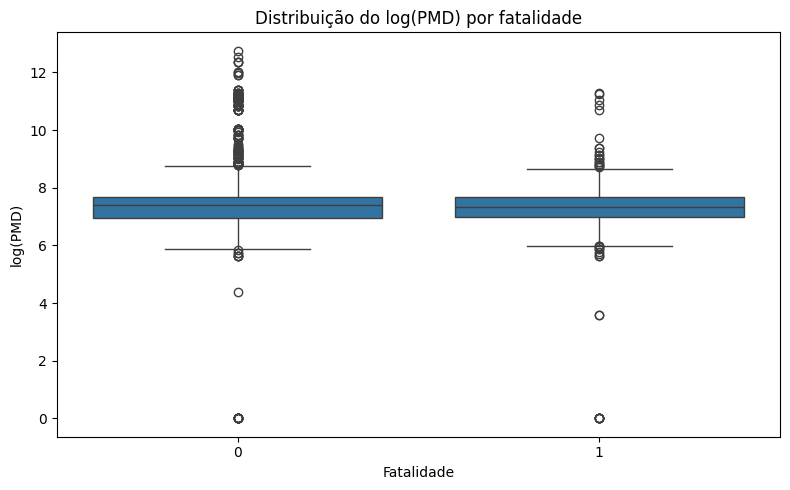

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=ocorrencias_selec,
    x='Fatalidade',
    y='PMD_log'
)

plt.title('Distribuição do log(PMD) por fatalidade')
plt.xlabel('Fatalidade')
plt.ylabel('log(PMD)')

salvar('fig_boxplot_pmd.png')
plt.show()


#####Conseguimos ver, no boxplot e nas estatísticas descritivas, que a média do PMD dos aviões em que ocorrem fatalidades, são menores. Além disso, temos que a variabilidade da distribuição do PMD dos aviões que tem fatalidade, é muito menor,  com muito menos observação, do que  a distribuição do PMD dos incidentes que não tem fatalidade

##Fase Crítica

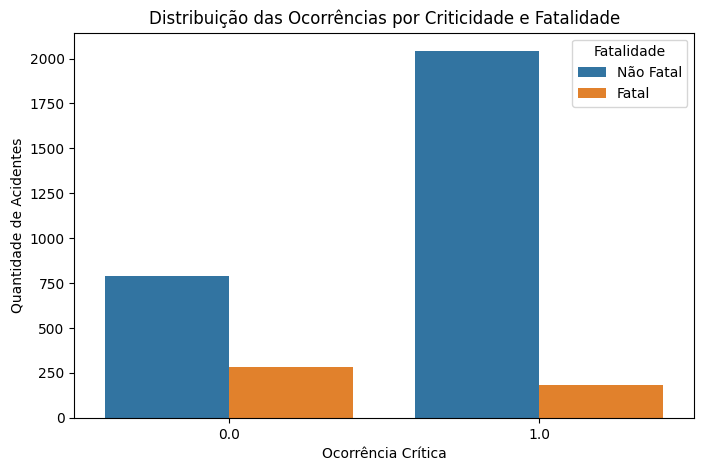

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=ocorrencias_selec,
    x='critico',
    hue='Fatalidade'
)

plt.title('Distribuição das Ocorrências por Criticidade e Fatalidade')
plt.xlabel('Ocorrência Crítica')
plt.ylabel('Quantidade de Acidentes')

plt.legend(
    title='Fatalidade',
    labels=['Não Fatal', 'Fatal']
)

plt.show()

In [ ]:
pd.crosstab(
    ocorrencias_selec['critico'],
    ocorrencias_selec['Fatalidade'],
    normalize='index'
)

Fatalidade,0,1
critico,,
0.0,0.736891,0.263109
1.0,0.916929,0.083071


####Como podemos observar, analisando os 2 gráficos, temos um numero maior de acidentes, em fases críticas do que em fases não críticas. No entanto, quando temos acidentes em fases não críticas, a gravidade é maior, por isso, dado que temos uma acidente em uma fase não crítica, a chance de termos uma fatalidade, é 4 vezes maior que uma acidente com fatalidade em uma fase crítica.

##Tipo de Ocorrência

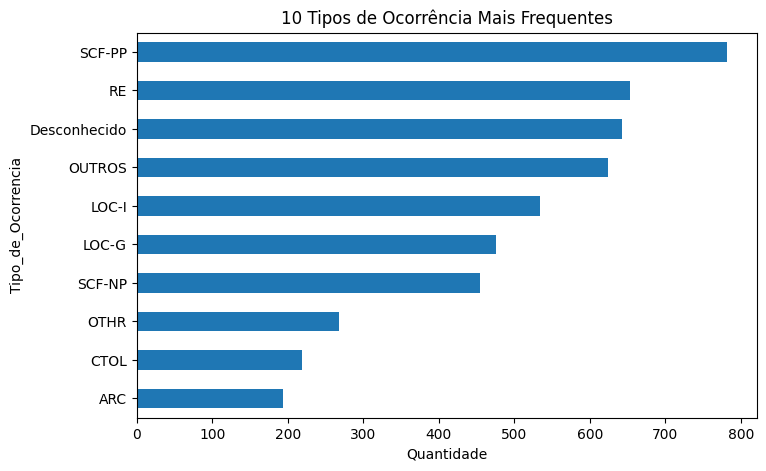

In [ ]:
freq = ocorrencias_selec['Tipo_de_Ocorrencia'].value_counts()

freq.head(10)
freq.head(10).sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('10 Tipos de Ocorrência Mais Frequentes')
plt.xlabel('Quantidade')
plt.show()

In [ ]:
taxa = pd.crosstab(
    ocorrencias_selec['Tipo_de_Ocorrencia'],
    ocorrencias_selec['Fatalidade'],
    normalize='index'
)
taxa[1].sort_values(ascending=False).head(10)

,1
Tipo_de_Ocorrencia,
UNK,0.534091
LOC-I,0.425094
Desconhecido,0.299065
CTOL,0.242009
OUTROS,0.171474
OTHR,0.152985
SCF-PP,0.090793
SCF-NP,0.066079
LOC-G,0.018908


#####Vamos la, temos que, os valores com o codigo de ocorrencia 'UNKNOWN', 'LOC', ' Desconhecido' e 'CTOL' tem as maiores proporções de acidentes com fatalidades. Ja foi detalhado acima o que cada código significa e uma possível interpretação do porque isso acontece. Lembrando que os valores 'Desconhecido', são de celulas com valores faltantes ('NaN')

##Análise da distribuição da variável-alvo 'Fatalidade':

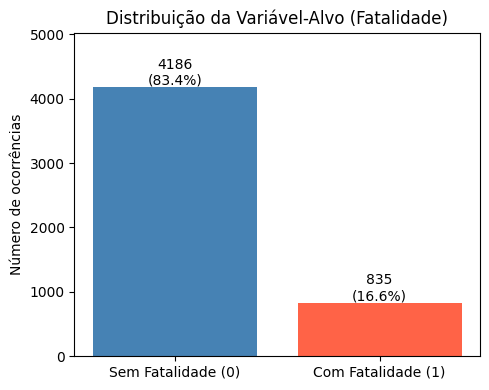

In [ ]:
contagem = y.value_counts()
rotulos  = ['Sem Fatalidade (0)', 'Com Fatalidade (1)']

plt.figure(figsize=(5, 4))
bars = plt.bar(rotulos, contagem.values, color=['steelblue', 'tomato'])
for bar, val in zip(bars, contagem.values):
    pct = val / len(y) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val}\n({pct:.1f}%)', ha='center', fontsize=10)
plt.title('Distribuição da Variável-Alvo (Fatalidade)')
plt.ylabel('Número de ocorrências')
plt.ylim(0, contagem.max() * 1.2)
salvar('fig1_distribuicao_fatalidade.png')

#Análise de Dados do Modelo definitivo e Salvar Gráficos


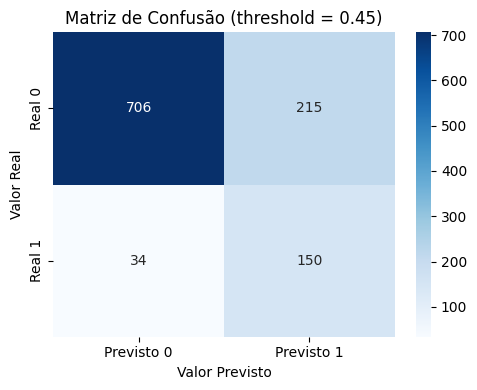

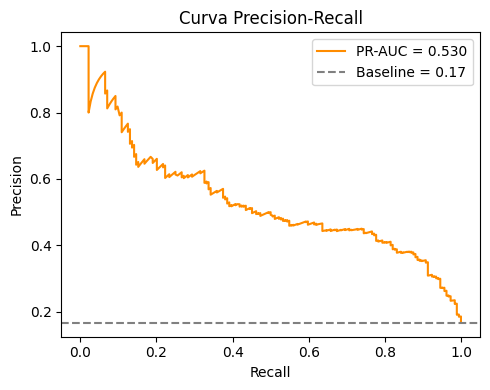

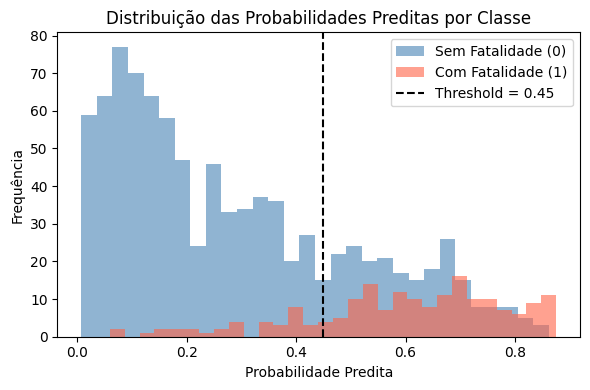


--- Tabela: Comparativo de Thresholds - Random Forest ---
 Threshold  Precision  Recall  F1-score
      0.39       0.38    0.87      0.53
      0.45       0.41    0.82      0.54
      0.51       0.44    0.74      0.55

--- Tabela: Comparativo de Thresholds - XG_BOOST ---
 Threshold  Precision  Recall  F1-score
      0.39       0.33    0.90      0.48
      0.45       0.37    0.86      0.52
      0.51       0.41    0.82      0.54


In [ ]:


#Heatmap da Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_new)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto 0', 'Previsto 1'],
            yticklabels=['Real 0', 'Real 1'])
plt.title('Matriz de Confusão (threshold = 0.45)')
plt.ylabel('Valor Real')
plt.xlabel('Valor Previsto')
salvar('fig_matriz_confusao.png')

#Gráfico da Curva Precision-Recall

precision, recall, _ = precision_recall_curve(y_test, y_prob[:, 1])
pr_auc    = auc(recall, precision)
baseline  = y_test.mean()

plt.figure(figsize=(5, 4))
plt.plot(recall, precision, color='darkorange', label=f'PR-AUC = {pr_auc:.3f}')
plt.axhline(baseline, linestyle='--', color='gray', label=f'Baseline = {baseline:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
salvar('fig_curva_pr.png')


# Histograma de probabilidades preditas por classes
probs = y_prob[:, 1]

plt.figure(figsize=(6, 4))
plt.hist(probs[y_test == 0], bins=30, alpha=0.6, color='steelblue',  label='Sem Fatalidade (0)')
plt.hist(probs[y_test == 1], bins=30, alpha=0.6, color='tomato',     label='Com Fatalidade (1)')
plt.axvline(0.45, color='black', linestyle='--', label='Threshold = 0.45')
plt.xlabel('Probabilidade Predita')
plt.ylabel('Frequência')
plt.title('Distribuição das Probabilidades Preditas por Classe')
plt.legend()
salvar('fig_histograma_probs.png')

#Tabela comparativa de thresholds
tabela_comparativa = pd.DataFrame({
    'Threshold': [0.39, 0.45, 0.51],
    'Precision': [0.38, 0.41, 0.44],
    'Recall':    [0.87, 0.82, 0.74],
    'F1-score':  [0.53, 0.54, 0.55],
})


print("\n--- Tabela: Comparativo de Thresholds - Random Forest ---")
print(tabela_comparativa.to_string(index=False))

tabela_comparativa_XGboost = pd.DataFrame({
    'Threshold': [0.39, 0.45, 0.51],
    'Precision': [0.33,0.37,0.41],
    'Recall':    [0.9, 0.86, 0.82],
    'F1-score':  [0.48, 0.52, 0.54],
})
print("\n--- Tabela: Comparativo de Thresholds - XG_BOOST ---")
print(tabela_comparativa_XGboost.to_string(index=False))